<a href="https://colab.research.google.com/github/ooyoomilkis/DEMOCAMVLM1/blob/main/Copy_of_rynnbrain_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RynnBrain Playground — Embodied VLM Exploration

Welcome! This notebook is a hands-on starting point for exploring
[**RynnBrain**](https://github.com/alibaba-damo-academy/RynnBrain), an
open-source embodied foundation model (built on top of Qwen3-VL) released
by Alibaba DAMO Academy.

[**Link to Paper**](https://arxiv.org/abs/2602.14979v1)

The lab's research focus is **socially assistive robotics (SAR)**, but
the example data here is for a **basic imitation-learning task** with
state, action, and image observations. The goal of this notebook is to
give you a guided tour of every capability RynnBrain exposes — so you
can decide which ones are useful for future SAR projects or for the imitation learning labeling task.

## What this notebook covers

This notebook walks through the 11 official cookbooks plus the model
loading and visualization scaffolding you need to use them:

| # | Capability | Cookbook |
|---|---|---|
| 1 | Spatial understanding (image / video) | `1_spatial_understanding` |
| 2 | Object understanding & counting | `2_object_understanding` |
| 3 | Egocentric OCR | `3_ocr` |
| 4 | Object location (bounding boxes) | `4_object_location` |
| 5 | Area location (points) | `5_area_location` |
| 6 | Affordance location | `6_affordance_location` |
| 7 | Trajectory location | `7_trajectory_location` |
| 8 | Grasp pose prediction | `8_grasp_pose` |
| 9 | Interleaved reasoning ("thinking with time and space") | `9_thinking_with_time_space` |
| 10 | Manipulation planning | `10_manipulate_planning` |
| 11 | Vision-language navigation | `11_visual_language_navigation` |

## Environment assumptions

- **Google Colab** (Runtime → Change runtime type → **T4 GPU**)
- ~15 GB GPU VRAM, ~12 GB system RAM, ~80 GB disk
- We use `RynnBrain-2B` in bf16 with `sdpa` attention. T4 is `sm_75`
  and **does not support FlashAttention-2** (which needs `sm_80+`),
  so do *not* try to enable `attn_implementation="flash_attention_2"`.
- The 8B and 30B variants will not fit on a single T4. If you want to
  try them, use an A100 runtime or 4-bit `bitsandbytes` quantization.

## How to use it

Run the cells top-to-bottom the first time. Each section is independent
once the model is loaded, so after that you can jump around freely. The
sections that need *your* imitation-learning data have a clearly marked
`# TODO` block — until then, the cells run on a sample image we pull
from the RynnBrain repo so you can see real output end-to-end.


---
## 1. Macros and paths

All tunable knobs live here so you only edit one cell when you switch
models, change where your data lives, or tweak generation settings.


In [ ]:
# ---- Model -------------------------------------------------------------
# We default to the 2B model because it is the only RynnBrain variant that
# fits comfortably on a T4 in bf16. Other options (require more VRAM):
#   "Alibaba-DAMO-Academy/RynnBrain-8B"        (~16 GB bf16; A100/L4 only)
#   "Alibaba-DAMO-Academy/RynnBrain-Plan-8B"   (planning-tuned 8B)
#   "Alibaba-DAMO-Academy/RynnBrain-CoP-8B"    (chain-of-point reasoning 8B)
#   "Alibaba-DAMO-Academy/RynnBrain-Nav-8B"    (navigation-tuned 8B)
MODEL_ID = "Alibaba-DAMO-Academy/RynnBrain-2B"

# ---- Generation defaults -----------------------------------------------
# RynnBrain inherits Qwen3-VL's chat template. For grounding tasks
# (bboxes, points, trajectories) low temperature is best.
GEN_KWARGS_GROUNDING = dict(max_new_tokens=512, do_sample=False)
GEN_KWARGS_FREEFORM  = dict(max_new_tokens=1024, do_sample=True,
                            temperature=0.7, top_p=0.95)

# ---- Coordinate convention ---------------------------------------------
# RynnBrain (and Qwen3-VL) outputs spatial coordinates in a normalized
# [0, 1000] integer space. We always rescale them back to actual image
# pixel dimensions before drawing or comparing.
COORD_RANGE = 1000

# ---- Video sampling ----------------------------------------------------
# Qwen3-VL is a frame-based model. For an imitation episode we stitch
# the per-step images into a video at this FPS. 2 FPS matches the value
# used in RynnBrain's pretraining / RynnBrain-Bench.
VIDEO_FPS = 2
# Cap the number of frames so we don't blow up T4 memory. At 2 FPS, 32
# frames = 16 s of "video", which is plenty for short manipulation eps.
MAX_VIDEO_FRAMES = 32

# ---- Pixel budget per image (Qwen3-VL processor knob) ------------------
# Smaller -> faster + less VRAM, but coarser localization. Larger ->
# slower but better fine-grained pointing. These are token counts, not
# pixels; min/max get multiplied by 28*28 internally.
IMAGE_MIN_PIXELS = 256 * 28 * 28
IMAGE_MAX_PIXELS = 1280 * 28 * 28

# ---- Paths -------------------------------------------------------------
import os
WORKDIR    = "/content/rynnbrain_playground"
DATA_DIR   = os.path.join(WORKDIR, "data")        # ignore
ASSETS_DIR = os.path.join(WORKDIR, "assets")      # sample images we download
OUT_DIR    = os.path.join(WORKDIR, "outputs")     # rendered videos & visualizations will be here
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(ASSETS_DIR, exist_ok=True)
os.makedirs(OUT_DIR,    exist_ok=True)
print("Workdir:", WORKDIR)


Workdir: /content/rynnbrain_playground


---
## 2. Install dependencies

`pip install` block. Run **once per Colab session** — Colab's VM is
ephemeral so it'll need to be re-run if the runtime restarts.

- `transformers>=4.57` is the version pinned in RynnBrain's README; it
  is the first version that ships the Qwen3-VL model class
  (`AutoModelForImageTextToText`).
- `qwen-vl-utils` provides the `process_vision_info` helper that turns
  the chat-template message list into batched image / video tensors.
- `accelerate` is needed by `device_map="auto"`.
- `imageio[ffmpeg]` lets us stitch a list of frames into an mp4 for the
  video tasks.


In [ ]:
!pip install -q "transformers>=4.57.0" "qwen-vl-utils>=0.0.14" "accelerate>=0.34" "imageio[ffmpeg]" "pillow" "matplotlib"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 43.6 MB/s eta 0:00:00


---
## 3. Imports

All Python imports for the rest of the notebook. We group them by
category so you can quickly see what each block is for.


In [ ]:
# Note: Imports can take ~30 seconds to complete
# ---- Standard library --------------------------------------------------
import os, re, json, math, gc, random
from pathlib import Path
from typing import List, Tuple, Dict, Any, Optional, Union
import io

# ---- Numerical / imaging ----------------------------------------------
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
import imageio.v2 as imageio
import pandas as pd

# ---- Torch + HuggingFace ----------------------------------------------
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from qwen_vl_utils import process_vision_info

# ---- Sanity checks -----------------------------------------------------
print("Torch:", torch.__version__,
      "| CUDA:", torch.cuda.is_available(),
      "| Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Torch: 2.10.0+cu128 | CUDA: True | Device: Tesla T4


---
## 4. Load the model

We load `RynnBrain-2B` in bfloat16 with the `sdpa` attention backend.

**Why `sdpa` and not `flash_attention_2`?** The T4 is a Turing GPU
(`sm_75`). FlashAttention-2 requires Ampere or newer (`sm_80+`), so
turning it on will crash. PyTorch's built-in
`torch.nn.functional.scaled_dot_product_attention` (`"sdpa"`) is the
fastest backend that actually works on a T4.

The first time this cell runs it will download ~5 GB of weights from
the HuggingFace hub. Subsequent runs in the same Colab session will be
much faster because Colab caches the weights at `~/.cache/huggingface`.


In [ ]:
# Note: This cell can take ~2-3 minutes to run
# Free anything from a previous run before we allocate a new model.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=IMAGE_MIN_PIXELS,
    max_pixels=IMAGE_MAX_PIXELS,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,           # T4 supports bf16 compute via mixed precision
    attn_implementation="sdpa",     # NOT flash_attention_2 -- T4 is sm_75
    device_map="auto",
).eval()

print("Loaded:", MODEL_ID)
print("Param count:", sum(p.numel() for p in model.parameters()) / 1e9, "B")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/626 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/199 [00:00<?, ?B/s]

Loaded: Alibaba-DAMO-Academy/RynnBrain-2B
Param count: 2.43869696 B


---
## 5. Core inference helper

Every cookbook follows the same recipe:

1. Build a `messages` list (chat template) containing image / video
   blocks and a text prompt.
2. Run `processor.apply_chat_template(...)` to get the formatted prompt
   string, then `process_vision_info(...)` to extract the visual
   tensors.
3. Call `model.generate(...)` and decode the *new* tokens only.

We wrap that in a single `run_rynnbrain(...)` function so the rest of
the notebook is just "build messages, call the function, parse the
answer".


In [ ]:
def run_rynnbrain(messages: List[Dict[str, Any]],
                  generation_kwargs: Optional[Dict[str, Any]] = None) -> str:
    '''
    Send a chat-formatted message list to RynnBrain and return the decoded
    string. `messages` follows the standard Qwen3-VL/HF format:

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": <PIL.Image or path or url>},
                {"type": "text",  "text":  "your prompt"},
            ],
        }]

    For video, replace "image" with "video" and pass either an mp4 path
    or a list of PIL frames; you can also pass `fps=...` and
    `max_pixels=...` per-clip inside the dict.
    '''
    if generation_kwargs is None:
        generation_kwargs = GEN_KWARGS_GROUNDING

    # 1) Render the chat template (also returns model-ready tensors).
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
        # Newer qwen-vl-utils integrates with apply_chat_template directly,
        # but to be safe across versions we also call process_vision_info
        # below if the kwargs above didn't ingest the visuals.
    )
    if "pixel_values" not in inputs and "pixel_values_videos" not in inputs:
        # Fallback path for older qwen-vl-utils versions: build the prompt
        # text first, then attach visuals separately.
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **generation_kwargs)

    # Slice off the prompt tokens; only decode the model's *new* output.
    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], generated_ids)]
    return processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]


---
## 6. Utility functions

These are the workhorses we re-use in every section:

- **Image loading** — RynnBrain wants PIL `RGB` images; never feed it a
  numpy `BGR` array straight from OpenCV.
- **Video stitching** — your imitation episodes are stored as a list
  of per-step images. For the video-based cookbooks we need to glue
  them into an mp4 first.
- **Output parsing** — RynnBrain emits coordinates in well-defined
  string formats (e.g. `<object> (x1, y1), (x2, y2) </object>`). We
  parse those with regexes and **renormalize from `[0, 1000]` back to
  pixel coordinates**.
- **Drawing** — overlay the parsed boxes / points / trajectories on
  the original image with matplotlib.


In [ ]:
# ---------------------------------------------------------------------- #
# 6a. Image loading
# ---------------------------------------------------------------------- #
def load_image(path_or_url: Union[str, Path]) -> Image.Image:
    '''Load an image with PIL and force RGB. Accepts local path or URL.'''
    path = str(path_or_url)
    if path.startswith(("http://", "https://")):
        import requests, io
        img = Image.open(io.BytesIO(requests.get(path, timeout=30).content))
    else:
        img = Image.open(path)
    return img.convert("RGB")


# ---------------------------------------------------------------------- #
# 6b. Stitch a list of PIL frames into an mp4 video (for previewing /
#     saving), AND prepare the same list in a form RynnBrain can consume
#     directly without ever touching an mp4.
#
# Why both? `qwen-vl-utils` is picky about mp4 headers; it ships with a
# decord/torchvision backend that sometimes fails to open small or
# unusual mp4s with "Could not open input file ... Invalid data found
# when processing input". The robust workaround is to pass a *list of
# PIL frames* directly as the video input, which is one of the natively
# supported shapes for Qwen3-VL / RynnBrain. We still write the mp4 so
# you can preview the episode in the notebook UI.
# ---------------------------------------------------------------------- #
def stitch_video(frames: List[Image.Image],
                 out_path: str,
                 fps: int = VIDEO_FPS,
                 max_frames: int = MAX_VIDEO_FRAMES) -> str:
    '''
    Write a list of PIL frames to `out_path` as an mp4. If there are more
    than `max_frames` frames we evenly subsample (keeping first & last).
    Returns the output path. Use this for previewing the episode -- for
    inference, prefer `frames_for_video_input` below.
    '''
    if len(frames) == 0:
        raise ValueError("stitch_video got 0 frames")
    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames) - 1, max_frames).astype(int)
        frames = [frames[i] for i in idx]

    # Ensure even dimensions (yuv420p / libx264 require even W and H)
    # and force RGB in PIL before handing numpy arrays to imageio.
    def _to_even_rgb(im: Image.Image) -> np.ndarray:
        im = im.convert("RGB")
        w, h = im.size
        w2, h2 = (w // 2) * 2, (h // 2) * 2
        if (w2, h2) != (w, h):
            im = im.resize((w2, h2), Image.BILINEAR)
        return np.array(im)

    arrs = [_to_even_rgb(f) for f in frames]
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # Use yuv420p (the most universally decodable pixel format) and an
    # explicit framerate. macro_block_size=1 lets imageio accept any
    # even resolution without auto-padding to a multiple of 16.
    with imageio.get_writer(
        out_path,
        fps=fps,
        codec="libx264",
        pixelformat="yuv420p",
        macro_block_size=1,
        ffmpeg_params=["-movflags", "+faststart"],
    ) as w:
        for a in arrs:
            w.append_data(a)
    print(f"Wrote {len(arrs)} frames @ {fps} fps -> {out_path}")
    return out_path


def frames_for_video_input(frames: List[Image.Image],
                           max_frames: int = MAX_VIDEO_FRAMES
                           ) -> List[Image.Image]:
    '''
    Produce a list of PIL frames suitable for direct use as the value of
    a {"type": "video", "video": ...} message in RynnBrain's chat
    template. Subsamples to at most `max_frames` and forces RGB. Use
    this for *inference* -- it skips the mp4 encode/decode round-trip
    entirely and avoids backend-specific decoder issues.
    '''
    if len(frames) == 0:
        raise ValueError("frames_for_video_input got 0 frames")
    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames) - 1, max_frames).astype(int)
        frames = [frames[i] for i in idx]
    return [f.convert("RGB") for f in frames]


# ---------------------------------------------------------------------- #
# 6c. Parsing helpers
#
# RynnBrain returns coordinates in a normalized [0, 1000] integer space
# (the same convention as Qwen3-VL grounding). Every parser below
# RESCALES THE COORDINATES BACK TO PIXEL UNITS using the actual image
# width/height -- this step is mandatory before drawing or before
# comparing to ground-truth annotations.
# ---------------------------------------------------------------------- #
def _denorm(x: float, full: int) -> float:
    return float(x) / COORD_RANGE * full


def parse_bboxes(text: str, img_w: int, img_h: int
                 ) -> List[Tuple[float, float, float, float]]:
    '''
    Pull out all `<object> (x1, y1), (x2, y2) </object>` spans and
    rescale to pixel units.
    '''
    pattern = re.compile(
        r"<object>\s*\(?\s*(\d+)\s*,\s*(\d+)\s*\)?\s*,\s*"
        r"\(?\s*(\d+)\s*,\s*(\d+)\s*\)?\s*</object>",
        re.IGNORECASE,
    )
    out = []
    for m in pattern.finditer(text):
        x1, y1, x2, y2 = map(int, m.groups())
        out.append((
            _denorm(x1, img_w), _denorm(y1, img_h),
            _denorm(x2, img_w), _denorm(y2, img_h),
        ))
    return out


def parse_points(text: str, img_w: int, img_h: int
                 ) -> List[Tuple[float, float]]:
    '''
    Pull out point lists like `<point> (x1, y1), (x2, y2), ... </point>`
    or bare `(x, y)` tuples and rescale to pixels.
    '''
    # Prefer points wrapped in <point>...</point> if present.
    blocks = re.findall(r"<point[^>]*>(.*?)</point>", text, flags=re.IGNORECASE | re.DOTALL)
    haystack = " ".join(blocks) if blocks else text
    coords = re.findall(r"\(\s*(\d+)\s*,\s*(\d+)\s*\)", haystack)
    return [(_denorm(int(x), img_w), _denorm(int(y), img_h)) for x, y in coords]


def parse_trajectory(text: str, img_w: int, img_h: int
                     ) -> List[Tuple[float, float]]:
    '''
    Trajectories are emitted as an ordered list of points; treat them
    the same way as `parse_points` but preserve order.
    '''
    return parse_points(text, img_w, img_h)


# ---------------------------------------------------------------------- #
# 6d. Drawing helpers
# ---------------------------------------------------------------------- #
def show_image_with_boxes(img: Image.Image,
                          boxes: List[Tuple[float, float, float, float]],
                          labels: Optional[List[str]] = None,
                          title: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor="lime", facecolor="none",
        ))
        if labels and i < len(labels):
            ax.text(x1, max(0, y1 - 6), labels[i],
                    color="black", fontsize=11,
                    bbox=dict(facecolor="lime", alpha=0.8, pad=2, edgecolor="none"))
    ax.set_title(title); ax.axis("off"); plt.show()


def show_image_with_points(img: Image.Image,
                           points: List[Tuple[float, float]],
                           title: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    if points:
        xs, ys = zip(*points)
        ax.scatter(xs, ys, s=120, c="red", edgecolors="white", linewidths=2, zorder=3)
        for i, (x, y) in enumerate(points):
            ax.text(x + 8, y - 8, str(i), color="white", fontsize=10,
                    bbox=dict(facecolor="red", alpha=0.7, pad=1, edgecolor="none"))
    ax.set_title(title); ax.axis("off"); plt.show()


def show_image_with_trajectory(img: Image.Image,
                               traj: List[Tuple[float, float]],
                               title: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    if len(traj) >= 2:
        xs, ys = zip(*traj)
        # Color each segment by its index along the path.
        segs = [[(xs[i], ys[i]), (xs[i+1], ys[i+1])] for i in range(len(xs) - 1)]
        lc = LineCollection(segs, cmap="plasma",
                            array=np.linspace(0, 1, len(segs)), linewidths=4)
        ax.add_collection(lc)
        ax.scatter(xs[0], ys[0], s=160, c="lime", edgecolors="black",
                   linewidths=2, label="start", zorder=4)
        ax.scatter(xs[-1], ys[-1], s=160, c="red", edgecolors="black",
                   linewidths=2, label="end", zorder=4)
        ax.legend(loc="lower right")
    ax.set_title(title); ax.axis("off"); plt.show()


---
## 6A. Utility functions for Imitation Learning Dataset

These are the helpers used to load and clean the imitation learning dataset


In [ ]:
def get_folder_paths(path):
    rgb_folder = os.path.join(path, "HeadCamImagesRGB")
    gripper_cam_folder = os.path.join(path, "GripperCamImages")
    depth_cam_folder = os.path.join(path, "HeadCamImagesDepth")
    bitoac_folder = os.path.join(path, "BiotacData")
    arm_angle_folder = os.path.join(path, "ArmAngleData")

    return rgb_folder, gripper_cam_folder, depth_cam_folder, bitoac_folder, arm_angle_folder
# Needed for sorting episodes numerically
def extract_number(s):
    # This will find all groups of digits in the string and return the last one as an integer
    numbers = re.findall(r'\d+', s)
    return int(numbers[-1]) if numbers else 0

def load_images(folder_path, sort_type = "numeric", image_type = "rgb"):
    image_paths = [os.path.join(folder_path, filename) for filename in os.listdir(folder_path)]
    sorted_image_paths = sorted(image_paths, key = extract_number)

    if image_type == "rgb":
        images = [Image.open(i) for i in sorted_image_paths]
    else:
        raise NotImplementedError

    return images

def load_csv_data(path, data_type = "biotac"):
    with open(path, 'r') as f:
        cleaned_lines = [line.rstrip(",\n") for line in f]
        df = pd.read_csv(io.StringIO("\n".join(cleaned_lines)), header = None)
    if data_type == "biotac":
        return_df = df.iloc[:, 3:].copy() # Remove timestamp information
        input_data = return_df.iloc[:-1].copy()
        output_data = return_df.iloc[1:].copy()
        # df = df.iloc[:-1] # ... only needed when setting up I/O data
    elif data_type == "arm_angle":
        # TODO: adjust function to dynamically properly return data based on whether right only or both arms are being used ... currently set up for both arms
        right_arm = df.iloc[:, :7].copy()
        left_arm = df.iloc[:,9:16].copy()
        # combine right and left arm
        return_df = pd.concat([right_arm, left_arm], axis = 1)
        input_data = return_df.iloc[:-1].copy()
        output_data = return_df.iloc[1:].copy()

    return input_data, output_data

---
## 7. Sample assets and your imitation-learning data

Two pieces here:

1. **A sample image from the RynnBrain repo.** This makes the cookbook
   sections runnable end-to-end before you wire up your own data, so
   you can sanity-check the pipeline.
2. **A placeholder loader for your imitation-learning episodes.**
   You said you'll bring your own data utilities — drop them into the
   `load_episode(...)` function below. The rest of the notebook only
   touches that function, so you don't need to edit anything else.

### Expected episode interface

After `episode = load_episode(idx)`, the rest of the notebook expects:

| Field | Type | Shape |
|---|---|---|
| `episode["images"]` | `List[PIL.Image]` (RGB) | length `T` |
| `episode["states"]` | `np.ndarray` | `(T, state_dim)` |
| `episode["actions"]` | `np.ndarray` | `(T, action_dim)` |
| `episode["language_instruction"]` | `str` (optional) | — |

`T` is the number of timesteps in this episode. Only one episode is
loaded at a time per the task spec.


Sample image size (W x H): (640, 427)


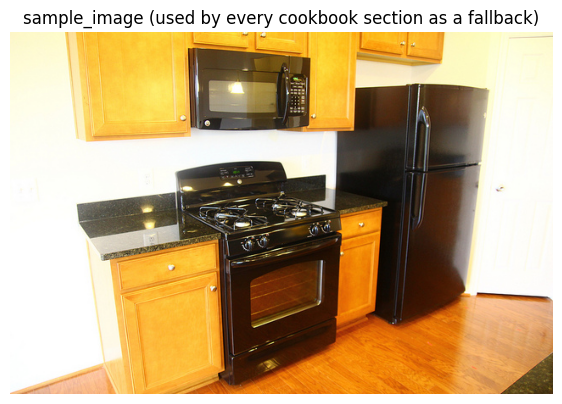

In [ ]:
# ---- 7a. Pull a sample image from the RynnBrain cookbooks ---------------
SAMPLE_IMAGE_URL = (
    "https://raw.githubusercontent.com/alibaba-damo-academy/RynnBrain/"
    "main/cookbooks/assets/object_location/images/000000086408.jpg"
)
SAMPLE_IMAGE_PATH = os.path.join(ASSETS_DIR, "sample_kitchen.jpg")

if not os.path.exists(SAMPLE_IMAGE_PATH):
    import urllib.request
    print("Downloading sample image...")
    urllib.request.urlretrieve(SAMPLE_IMAGE_URL, SAMPLE_IMAGE_PATH)

sample_image = load_image(SAMPLE_IMAGE_PATH)
print("Sample image size (W x H):", sample_image.size)
plt.figure(figsize=(7, 7)); plt.imshow(sample_image); plt.axis("off")
plt.title("sample_image (used by every cookbook section as a fallback)")
plt.show()


---
## **CHANGE custom_path below TO REFLECT THE EPISODE YOU WANT TO LOAD** ##
## **DO NOT REMOVE DRIVE MOUNTING CODE** ##
---

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')
# change the below path
custom_path = "/content/drive/MyDrive/Dish Rack Task Data/2025-12-20 16-08-37" # edit the date stamp at the end to reflect the episode you want to load

Mounted at /content/drive


Episode keys     : ['images', 'states', 'actions', 'language_instruction']
# frames         : 278
states.shape     : (278, 58)
actions.shape    : (278, 14)
instruction      : Retrieve the dish from the left arm and place it an empty slot in the dish rack


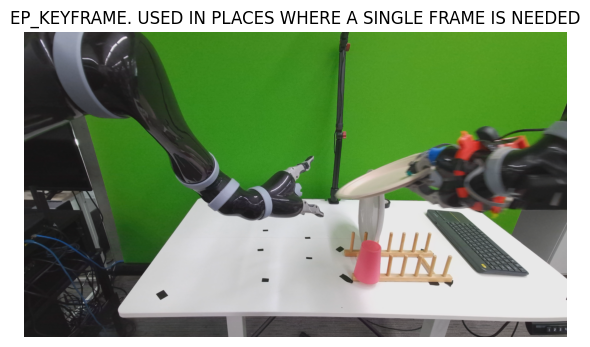

In [ ]:
# ---- 7b. YOUR imitation-learning episode loader -------------------------
#
# TODO (lab member): replace the body of `load_episode` with your own
# data-loading code. You said you'd provide utilities for non-image
# data and for sorting frames into the correct temporal order -- import
# them here and use them inside this function. The contract is:
#
#     episode = load_episode(idx)
#     episode["images"]   -> List[PIL.Image]   (length T, RGB)
#     episode["states"]   -> np.ndarray        (T, state_dim)
#     episode["actions"]  -> np.ndarray        (T, action_dim)
#     episode["language_instruction"] -> str   (optional, used by planning)
#
# Until you replace this, we return a synthetic 1-frame "episode" built
# from the sample image so the rest of the notebook still runs.

def load_episode(episode_root : str) -> Dict[str, Any]:

    rgb_path, gripper_path, depth_path, biotac_path, arm_angle_path = get_folder_paths(episode_root)
    biotac_path = os.path.join(biotac_path, "BioTacData.txt")
    arm_angle_path = os.path.join(arm_angle_path, "ArmAngleData.txt")
    biotac_data, _ = load_csv_data(biotac_path)
    arm_angle_states, arm_angle_actions = load_csv_data(arm_angle_path, data_type = "arm_angle")

    # now merge biotac and arm angle into single state mapping
    images = load_images(rgb_path, sort_type = "numeric", image_type = "rgb") # for images, currently only using head cam rgb... modify this script to use gripper and depth if wanted
    images.pop() # remove last image to match i/o structure
    states = pd.concat([arm_angle_states, biotac_data], axis = 1).to_numpy()
    actions = arm_angle_actions.to_numpy()

    return {
        "images": images,
        "states": states,
        "actions": actions,
        "language_instruction": "Retrieve the dish from the left arm and place it an empty slot in the dish rack",
    }
    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

# Quick sanity check + cache one episode for use across the cookbooks.
EP = load_episode(custom_path)
print("Episode keys     :", list(EP.keys()))
print("# frames         :", len(EP["images"]))
print("states.shape     :", EP["states"].shape)
print("actions.shape    :", EP["actions"].shape)
print("instruction      :", EP.get("language_instruction"))

# Convenience: a single representative frame ("middle of the episode")
# that we'll reuse anywhere a cookbook only needs one image.
EP_KEYFRAME = EP["images"][len(EP["images"]) // 2]
EP_START = EP["images"][0]
plt.figure(figsize=(7, 7)); plt.imshow(EP_KEYFRAME); plt.axis("off")
plt.title("EP_KEYFRAME. USED IN PLACES WHERE A SINGLE FRAME IS NEEDED")
plt.show()



In [ ]:
# ---- 7c. Prepare two video forms of the episode --------------------------
#
#  * EP_VIDEO_PATH    -> an mp4 you can preview from the file browser /
#                        re-use elsewhere, but DO NOT pass to the model
#                        directly. Some qwen-vl-utils backends fail on
#                        small/unusual mp4s with errors like
#                        "Could not open input file ... Invalid data".
#  * EP_VIDEO_FRAMES  -> a list of PIL frames you pass DIRECTLY into a
#                        {"type": "video", "video": EP_VIDEO_FRAMES}
#                        block. This skips the mp4 encode/decode round
#                        trip entirely and is the recommended path for
#                        every video cookbook below.
EP_VIDEO_PATH   = os.path.join(OUT_DIR, "episode.mp4")
# MAX_VIDEO_FRAMES = len(EP["images"]) # can edit
# VIDEO_FPS = 15 # can edit
stitch_video(EP["images"], EP_VIDEO_PATH, fps=VIDEO_FPS, max_frames=MAX_VIDEO_FRAMES)

EP_VIDEO_FRAMES = frames_for_video_input(EP["images"], max_frames=MAX_VIDEO_FRAMES)
print(f"Prepared {len(EP_VIDEO_FRAMES)} PIL frames for video inference.")


Wrote 32 frames @ 2 fps -> /content/rynnbrain_playground/outputs/episode.mp4
Prepared 32 PIL frames for video inference.


---
## 8. Prompt library

Each cookbook has a canonical instruction string. Centralizing them
here makes it obvious what changes between tasks, and makes it easy
for you to A/B-test variations. Constraints (e.g. coordinate range,
output format) are baked into the prompt because RynnBrain follows the
format very strictly — deviating from these templates makes parsing
unreliable.

### Tuning prompts for better answers

The base templates below are intentionally generic. RynnBrain's outputs
get noticeably sharper when you **add scene context** the model can't
infer from a single image — and dramatically worse when you change the
output-format clauses, so leave those alone.

**1. Describe the embodiment.** A bimanual setup looks ambiguous from a
single camera. Tell the model what it's looking at:

- *"There are two robot arms in the scene: a **left** arm (stationary,
  acting as a fixture) and a **right** arm (the one performing the
  task). Reason only about the right arm's end-effector."*
- *"The robot has a parallel-jaw gripper. The 'fingers' are the two
  short black bars at the tip; ignore the wrist camera mounted above
  them."*
- *"This is an egocentric view from a head-mounted camera; the user's
  hands may enter the frame from below."*

**2. Anchor the camera and frame of reference.** Spatial answers ("to
the left of") collapse without this:

- *"The camera is fixed and faces the table from the operator's side.
  'Left' / 'right' refer to the camera's perspective, not the robot's."*
- *"The workspace is a 60 cm × 40 cm tabletop; objects beyond the table
  edge should be ignored."*

**3. Constrain the answer space.** Closed-set reasoning is far more
reliable than open-ended generation:

- For counting: add *"Answer must be an integer between 0 and 10."*
- For affordances: *"Choose exactly one contact point on the object's
  handle, not on its body."*
- For planning: *"The plan must use at most 5 sub-tasks. Each sub-task
  must reference exactly one object."*

**4. Disambiguate referents.** When a scene has multiple instances of
the same category, pin down which one with attributes the model can
actually see — color, position, size, relation to a landmark:

- Replace *"the cup"* with *"the **red** cup nearest the **right** edge
  of the table."*
- Replace *"the block"* with *"the small wooden block on top of the
  larger blue block."*

**5. Add task-specific scaffolding for SAR.** For socially assistive
contexts the model has weaker priors, so spell out the social setup:

- *"The person seated on the left is the user the robot is assisting.
  The person standing on the right is a caregiver and should not be
  interacted with."*
- *"The robot must hand the object to the user from the side, never
  reach across the user's body."*
- *"Treat any human hand entering the frame as a hard stop; output
  STOP if the gripper is within 10 cm of a hand."*

**6. Use few-shot examples for grounding tasks.** For bbox/point/traj
prompts, prepending one or two fully-formatted examples (with the
exact tag syntax) measurably improves both format compliance and
localization quality, especially on the 2B model. Keep the examples on
unrelated images so they teach format rather than content.

**7. What *not* to change.** Two things break parsing if you alter them:

- The output-format clauses (e.g. *"Format: `<object> (x1, y1), (x2, y2) </object>`"*) — the regexes in section 6c match these literally.
- The `[0, 1000]` coordinate range — RynnBrain's training distribution uses exactly this normalization.

**A/B testing recipe.** Copy a template into a new variable, edit the
context-setting parts, and re-run the cookbook cell. Because the
parsing helpers are decoupled from the prompt, swapping prompts never
breaks the visualization downstream.


In [ ]:
PROMPTS = {
    # Cookbook 1 -- spatial understanding (free-form QA)
    "spatial": (
        "Describe the spatial layout of the scene. Focus on the relative "
        "positions of the main objects (left/right/front/behind/on top of) "
        "and any obvious depth cues."
    ),

    # Cookbook 2 -- object understanding & counting
    "object_describe": (
        "List every distinct object you can see, then for each one give "
        "(a) its category, (b) its dominant color, and (c) its approximate "
        "material. Finish with a single line: 'TOTAL: <integer>'."
    ),
    "object_count": (
        "How many {target} are visible in this image? "
        "Answer with a single integer on its own line."
    ),

    # Cookbook 3 -- OCR
    "ocr": (
        "Transcribe every piece of readable text in this image. "
        "Preserve line breaks. If there is no text, reply 'NO TEXT'."
    ),

    # Cookbook 4 -- object location (bounding box)
    "bbox": (
        "{query}\n"
        "Generate coordinates for one object bounding box. "
        "Constraints: x1,y1,x2,y2 \u2208 [0,1000]. "
        "Response must be in the format: <object> (x1, y1), (x2, y2) </object>"
    ),
    "bbox_multi": (
        "Locate every {target} in the image. "
        "For each instance output one tag in the format "
        "<object> (x1, y1), (x2, y2) </object>. "
        "Coordinates are integers in [0, 1000]."
    ),

    # Cookbook 5 -- area location (points)
    "area": (
        "{query}\n"
        "Mark the region with one or more points. "
        "Coordinates x,y \u2208 [0, 1000]. "
        "Format: <point> (x1, y1), (x2, y2), ... </point>"
    ),

    # Cookbook 6 -- affordance location (where to interact)
    "affordance": (
        "Where on the image should the robot {action}? "
        "Output a single contact point that supports this affordance. "
        "Format: <point> (x, y) </point>, with x,y \u2208 [0, 1000]."
    ),

    # Cookbook 7 -- trajectory location
    "trajectory": (
        "Predict the end-effector trajectory required to {goal}. "
        "Return an ordered list of waypoints (start \u2192 end) as "
        "<point> (x1, y1), (x2, y2), ..., (xn, yn) </point>, "
        "with each x,y \u2208 [0, 1000]."
    ),

    # Cookbook 8 -- grasp pose
    "grasp": (
        "Predict a robotic grasp pose for the {target}. "
        "Return the two contact points of the parallel-jaw gripper as "
        "<point> (x1, y1), (x2, y2) </point>, x,y \u2208 [0, 1000]."
    ),

    # Cookbook 9 -- thinking with time + space (interleaved reasoning)
    "interleaved_reasoning": (
        "{question}\n"
        "Think step by step. Whenever you reference an object, ground it "
        "with a bounding box in the format "
        "<object> (x1, y1), (x2, y2) </object> (coords in [0, 1000]). "
        "End with a line beginning 'ANSWER:'."
    ),

    # Cookbook 10 -- manipulation planning
    "plan": (
        "You are the high-level planner for a manipulator. The user goal "
        "is: \"{goal}\". Decompose the goal into a numbered list of atomic "
        "sub-tasks. For each sub-task, ground the target object with "
        "<object> (x1, y1), (x2, y2) </object> and the placement / contact "
        "location with <point> (x, y) </point>. All coords are in [0, 1000]."
    ),

    # Cookbook 11 -- vision-language navigation
    "vln": (
        "Instruction: \"{instruction}\".\n"
        "Given the egocentric video of the agent's recent observations, "
        "decide the next motion primitive. Choose exactly one of: "
        "MOVE_FORWARD, TURN_LEFT, TURN_RIGHT, STOP. "
        "Briefly justify your choice in one sentence."
    ),
}
print("Loaded", len(PROMPTS), "prompt templates.")


Loaded 13 prompt templates.


---
## 9. Cookbook 1 — Spatial understanding

> *"Shows the model's ability for spatial understanding in the video scene."*

This is the simplest video-understanding task. We feed RynnBrain the
episode as a **list of PIL frames** (`EP_VIDEO_FRAMES`) and ask it to
describe the spatial layout. For SAR, this is useful for **scene
reporting** (e.g. "describe the user's living-room layout") or as a
sanity check that the model is parsing your camera feed at all.

Note: we pass a list of frames rather than the `.mp4` path. Some
versions of `qwen-vl-utils` fail to decode small/unusual mp4s with
errors like *"Could not open input file ... Invalid data found when
processing input"*, so the frame-list path is more reliable.


In [ ]:
messages = [{
    "role": "user",
    "content": [
        {"type": "video", "video": EP_VIDEO_FRAMES,
         "fps": VIDEO_FPS, "max_pixels": IMAGE_MAX_PIXELS},
        {"type": "text",  "text": PROMPTS["spatial"]},
    ],
}]
answer = run_rynnbrain(messages, GEN_KWARGS_FREEFORM)
print(answer)


Asked to sample `fps` frames per second but no video metadata was provided which is required when sampling with `fps`. Defaulting to `fps=24`. Please provide `video_metadata` for more accurate results.


The robot arm is positioned on the left side of the table, the green screen is behind the table, the wooden dish rack is to the right of the table, and the red and black object is on the right side of the table. The camera is facing the table from the front.


---
## 10. Cookbook 2 — Object understanding & counting

> *"Shows how the model understands object categories, attributes, relations, and counting."*

We run two queries on a single keyframe:
1. A free-form **describe-everything** prompt.
2. A targeted **count** prompt — replace `target` with whatever
   category you want a tally of.

For SAR, this is the foundation for state-tracking ("does the user
have a glass of water in front of them?"), inventory checks, and
basic cluttered-scene perception.


In [ ]:
# 10a. Free-form description
msg_describe = [{
    "role": "user",
    "content": [
        {"type": "image", "image": EP_START},
        {"type": "text",  "text": PROMPTS["object_describe"]},
    ],
}]
print("=== Object description ===")
print(run_rynnbrain(msg_describe, GEN_KWARGS_FREEFORM))


=== Object description ===
The objects are: plate, plate stand, keyboard, cup, camera, table. (a) their category is (b) plate is white, (b) plate stand is white, (b) keyboard is black, (b) cup is pink, (b) camera is black, (b) table is white. TOTAL: 6


In [ ]:
# 10b. Counting
COUNT_TARGET = "plate" # change to whatever you want to count
# notice this outputs 1 ... the smaller model size typically leads to worse performance
# If needed, we can run a larger model using one of our lab servers/gwu hpc
# but for now lets focus on experimentation and exploration
msg_count = [{
    "role": "user",
    "content": [
        {"type": "image", "image": EP_START},
        {"type": "text",  "text": PROMPTS["object_count"].format(target=COUNT_TARGET)},
    ],
}]
print(f"=== Count of '{COUNT_TARGET}' ===")
print(run_rynnbrain(msg_count, GEN_KWARGS_GROUNDING))


=== Count of 'plate' ===
1


---
## 11. Cookbook 3 — Egocentric OCR

> *"Optical character recognition and text understanding in videos."*

Reads any visible text in an image or video. In SAR this is useful for
reading medication labels, appliance displays, signs in a hallway, or
text on the user's phone — but only when the camera is close enough
for the text to actually be legible.


In [ ]:
msg_ocr = [{
    "role": "user",
    "content": [
        {"type": "image", "image": EP_KEYFRAME},
        {"type": "text",  "text": PROMPTS["ocr"]},
    ],
}]
print(run_rynnbrain(msg_ocr, GEN_KWARGS_GROUNDING))


NO TEXT


---
## 12. Cookbook 4 — Object location (bounding boxes)

> *"Locates specific objects with bounding boxes in an image or video based on instructions."*

This is the canonical **referring-expression detection** task and the
one with the most rigid output format. Two variants below:

1. **Single-instance, attribute-grounded query** ("the appliance that
   heats food quickly") — exactly the demo in the RynnBrain README.
2. **Multi-instance localization** of a category.

Note the renormalization step: the model writes `(x1, y1, x2, y2)` in
`[0, 1000]` integer space, and we map back to actual pixel coordinates
using `image.size` *before* drawing or comparing to ground truth.


Raw model output:
 <object> (506,425), (678,534) </object> 

Parsed (in pixel coords): [(647.6800000000001, 306.0, 867.84, 384.48)]


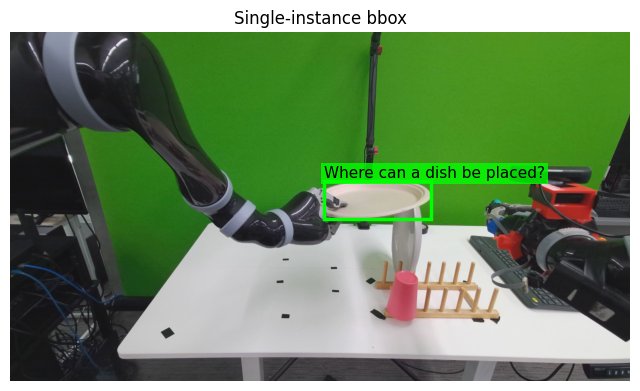

In [ ]:
# 12a. Single-instance referring expression on the sample (kitchen) image.
QUERY = "Empty space in the dish rack where a dish can be placed?"
img = EP_START
W, H = img.size

msg_bbox = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["bbox"].format(query=QUERY)},
    ],
}]
raw = run_rynnbrain(msg_bbox, GEN_KWARGS_GROUNDING)
print("Raw model output:\n", raw, "\n")

boxes = parse_bboxes(raw, W, H)                 # << renormalization happens here
print("Parsed (in pixel coords):", boxes)
show_image_with_boxes(img, boxes, labels=[QUERY], title="Single-instance bbox")


Raw model output:
 The object is <object> (511, 425), (678, 530) </object>. 

Found 1 instance(s) of 'plate' (pixel coords): [(654.08, 306.0, 867.84, 381.6)]


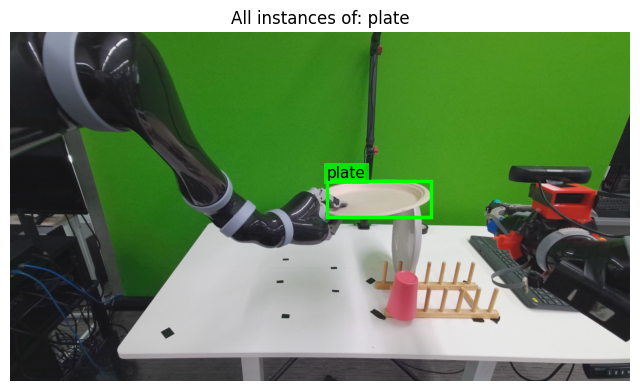

In [ ]:
# 12b. Multi-instance localization on the EP keyframe.
TARGET = "plate"   # try "cup", "chair", etc. on your own data
img = EP_START
W, H = img.size

msg_multi = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["bbox_multi"].format(target=TARGET)},
    ],
}]
raw = run_rynnbrain(msg_multi, GEN_KWARGS_GROUNDING)
print("Raw model output:\n", raw, "\n")

boxes = parse_bboxes(raw, W, H)
print(f"Found {len(boxes)} instance(s) of '{TARGET}' (pixel coords):", boxes)
show_image_with_boxes(img, boxes,
                      labels=[TARGET] * len(boxes),
                      title=f"All instances of: {TARGET}")


---
## 13. Cookbook 5 — Area location (points)

> *"Identifies and marks specified regions by points in an image or video."*

For regions that aren't well described by a tight bounding box (e.g.
"the empty area on the desk", "the floor zone in front of the user"),
RynnBrain marks them with one or more **points**.

Same `[0, 1000]` convention; we renormalize before plotting.


Raw: <area>(635, 472), (616, 465), (600, 465), (582, 465), (582, 465), (582, 465) </area>
Points (px): [(812.8, 339.84), (788.48, 334.8), (768.0, 334.8), (744.9599999999999, 334.8), (744.9599999999999, 334.8), (744.9599999999999, 334.8)]


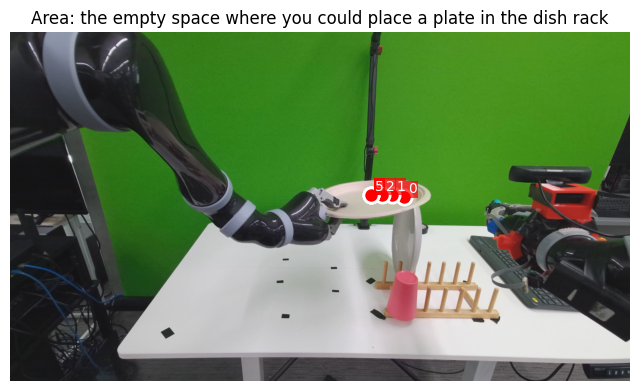

In [ ]:
AREA_QUERY = "empty space on the brown dish rack to the right of the pink cup where a dish can be placed"
img = EP_START
W, H = img.size

msg_area = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["area"].format(query=AREA_QUERY)},
    ],
}]
raw = run_rynnbrain(msg_area, GEN_KWARGS_GROUNDING)
print("Raw:", raw)
points = parse_points(raw, W, H)
print("Points (px):", points)
show_image_with_points(img, points, title=f"Area: {AREA_QUERY}")


---
## 14. Cookbook 6 — Affordance location

> *"Finds areas or objects with specific affordances in an image or video."*

Affordances are *interaction sites*: where to grab a mug (the handle),
where to press to open a microwave, where to place a hand to assist a
person sitting up. We output a single **contact point** per affordance.

This is one of the most directly useful capabilities for downstream
manipulation policies — it's the bridge between language ("open the
door") and a concrete goal pose for a controller.


Raw: <point> (595, 480) </point>
Affordance point(s) (px): [(761.5999999999999, 345.59999999999997)]


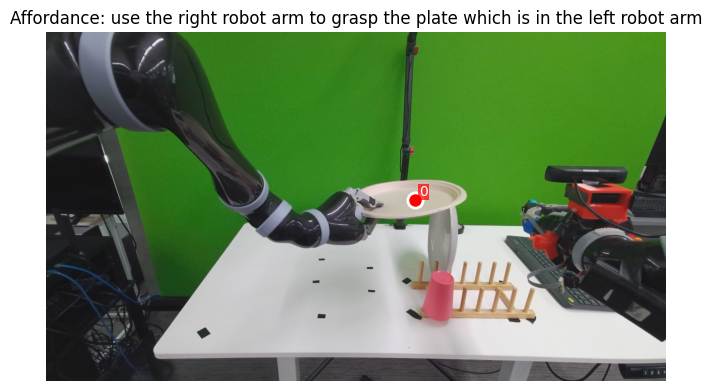

In [ ]:
AFFORDANCE_ACTION = "use the right robot arm to grasp the plate that is in the left robot arm"
img = EP_START
W, H = img.size

msg_aff = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["affordance"].format(action=AFFORDANCE_ACTION)},
    ],
}]
raw = run_rynnbrain(msg_aff, GEN_KWARGS_GROUNDING)
print("Raw:", raw)
points = parse_points(raw, W, H)
print("Affordance point(s) (px):", points)
show_image_with_points(img, points, title=f"Affordance: {AFFORDANCE_ACTION}")


---
## 15. Cookbook 7 — Trajectory location

> *"Infers and annotates trajectories or motion paths in an image or video."*

Returns an **ordered** list of 2D waypoints describing a path on the
image plane — for example, the path the gripper should take to
accomplish a goal, or the predicted trajectory of a moving object.

Caveats:
- These are 2D *image-plane* waypoints, **not** 3D world coordinates.
  You'll need camera intrinsics + depth to lift them.
- Order matters here. `parse_trajectory` preserves the order the model
  emitted; the coloring of the path goes start-of-traj (green) →
  end-of-traj (red).


Raw: <area>(585, 482), (570, 435), (552, 395), (530, 356) </area>
Trajectory has 4 waypoints (px).


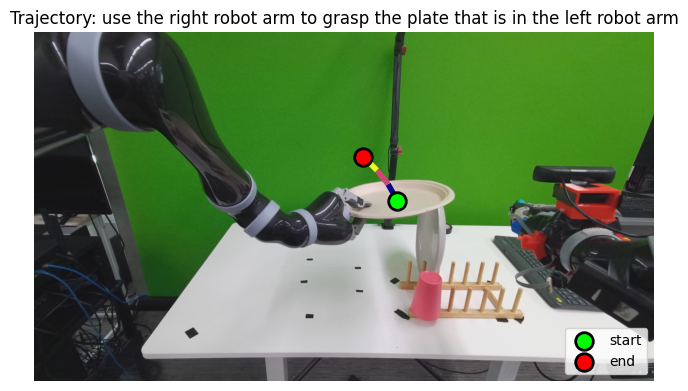

In [ ]:
TRAJ_GOAL = "use the right robot arm to grasp the plate that is in the left robot arm"
img = EP_START
W, H = img.size

msg_traj = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["trajectory"].format(goal=TRAJ_GOAL)},
    ],
}]
raw = run_rynnbrain(msg_traj, GEN_KWARGS_GROUNDING)
print("Raw:", raw)
traj = parse_trajectory(raw, W, H)
print(f"Trajectory has {len(traj)} waypoints (px).")
show_image_with_trajectory(img, traj, title=f"Trajectory: {TRAJ_GOAL}")


---
## 16. Cookbook 8 — Grasp pose

> *"Presents the model's ability to predict robotic grasp poses from images."*

Predicts a parallel-jaw grasp as the **two contact points** of the
finger pads. The line between the two points implicitly encodes both
the grasp axis (orientation) and the closing width.

For a SAR setting that includes object handover, this can be a quick
proposal mechanism — though for safety-critical contact you would
still want to verify with a dedicated grasp planner.


Raw: <area>(590, 482), (622, 496), (612, 526), (588, 512) </area>
Grasp contact points (px): [(755.1999999999999, 347.03999999999996), (796.16, 357.12), (783.36, 378.72), (752.64, 368.64)]


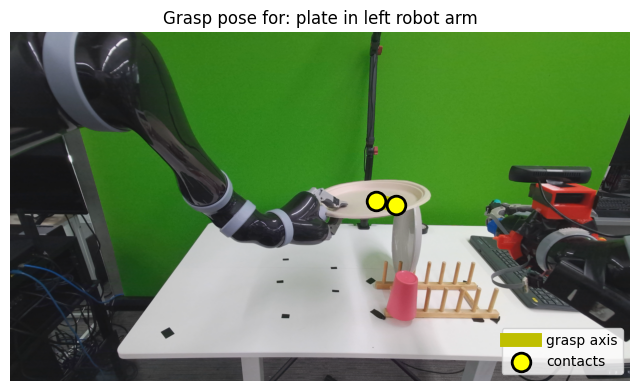

In [ ]:
GRASP_TARGET = "plate in left robot arm"
img = EP_START
W, H = img.size

msg_grasp = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["grasp"].format(target=GRASP_TARGET)},
    ],
}]
raw = run_rynnbrain(msg_grasp, GEN_KWARGS_GROUNDING)
print("Raw:", raw)
gp = parse_points(raw, W, H)
print("Grasp contact points (px):", gp)

# Visualize the two contacts AND the line between them (= gripper axis).
fig, ax = plt.subplots(1, 1, figsize=(8, 8)); ax.imshow(img)
if len(gp) >= 2:
    (x1, y1), (x2, y2) = gp[0], gp[1]
    ax.plot([x1, x2], [y1, y2], "y-", linewidth=10, label="grasp axis")
    ax.scatter([x1, x2], [y1, y2], s=180, c="yellow",
               edgecolors="black", linewidths=2, zorder=3, label="contacts")
    ax.legend(loc="lower right")
ax.set_title(f"Grasp pose for: {GRASP_TARGET}"); ax.axis("off"); plt.show()


---
## 17. Cookbook 9 — Interleaved reasoning ("thinking with time and space")

> *"An interleaved reasoning mechanism that alternates between textual reasoning and spatial grounding."*

This is the **chain-of-point (CoP)** style reasoning that the
`RynnBrain-CoP` post-trained model is best at. The base 2B model can
do a lighter version of it: when asked, it interleaves text reasoning
with `<object>...</object>` grounding tags, so each claim it makes is
visually anchored.

For SAR, this is the right primitive for "physically grounded
question answering" — e.g. "Did the user reach for their pill bottle?"


=== Reasoning trace ===
The object is <object> (508, 424), (679, 531) </object>.


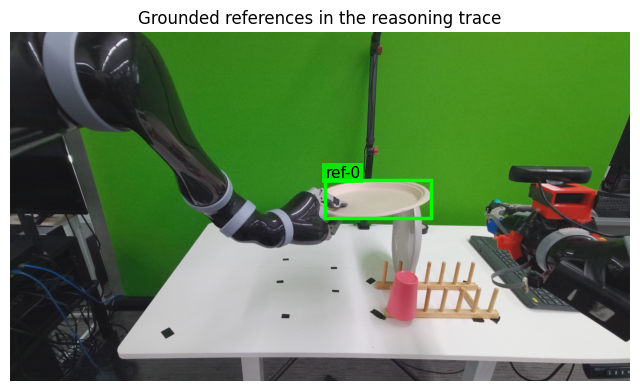

In [ ]:
QUESTION = "Looking at this scene, where should the plate be placed?"
img = EP_START
W, H = img.size

msg_cop = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["interleaved_reasoning"].format(question=QUESTION)},
    ],
}]
raw = run_rynnbrain(msg_cop, GEN_KWARGS_FREEFORM)
print("=== Reasoning trace ===")
print(raw)

# Visualize whatever boxes the model grounded its reasoning with.
boxes = parse_bboxes(raw, W, H)
if boxes:
    show_image_with_boxes(img, boxes,
                          labels=[f"ref-{i}" for i in range(len(boxes))],
                          title="Grounded references in the reasoning trace")


---
## 18. Cookbook 10 — Manipulation planning

> *"Multi-step task decomposition and action planning from goals and scenes."*

Given a high-level goal + scene, RynnBrain decomposes it into a list
of **atomic** sub-tasks, each one annotated with the relevant target
bbox and contact point. The dedicated `RynnBrain-Plan-8B` model is
much stronger at this than the 2B base, but the 2B output is good
enough to inspect the format and prototype a downstream policy.

For a hierarchical SAR system, this is the **high-level planner**
layer — it produces a structured plan that a low-level VLA / motion
planner can execute step by step.


=== Plan ===
1. <grasp pose> (510, 429), (791, 532), (765, 603), (485, 499) </grasp pose>

Grounded 0 object(s) and 4 contact point(s).


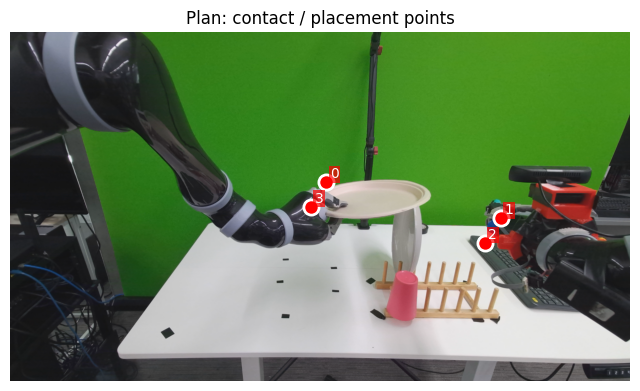

In [ ]:
# Use the imitation episode's own language instruction by default.
PLAN_GOAL = EP.get("language_instruction") or "tidy up the kitchen counter"
img = EP_START
W, H = img.size

msg_plan = [{
    "role": "user",
    "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPTS["plan"].format(goal=PLAN_GOAL)},
    ],
}]
raw = run_rynnbrain(msg_plan, GEN_KWARGS_FREEFORM)
print("=== Plan ===")
print(raw)

# Pull out grounded objects and contact points from the plan.
boxes  = parse_bboxes(raw, W, H)
points = parse_points(raw, W, H)
print(f"\nGrounded {len(boxes)} object(s) and {len(points)} contact point(s).")
if boxes:  show_image_with_boxes(img, boxes, title="Plan: target objects")
if points: show_image_with_points(img, points, title="Plan: contact / placement points")


---
## 19. Cookbook 11 — Vision-language navigation (VLN)

> *"Combines vision and language instructions to perform navigation and path planning."*

Given an instruction and a short egocentric video of the agent's most
recent observations, the model emits the next **motion primitive**.
For best results use the dedicated `RynnBrain-Nav-8B` checkpoint —
the 2B base will still produce reasonable outputs but is not
specialized for this task.

For SAR with a mobile base (e.g. a robot following a user from room
to room), this is the language-conditioned navigation primitive.


In [ ]:
NAV_INSTRUCTION = "go to the table and grasp the cup"

msg_vln = [{
    "role": "user",
    "content": [
        {"type": "video", "video": EP_VIDEO_FRAMES,
         "fps": VIDEO_FPS, "max_pixels": IMAGE_MAX_PIXELS},
        {"type": "text",  "text": PROMPTS["vln"].format(instruction=NAV_INSTRUCTION)},
    ],
}]
print(run_rynnbrain(msg_vln, GEN_KWARGS_FREEFORM))


STOP


---
## 20. Physical and temporal awareness probes

The cookbooks above each isolate one capability. This last section
combines them to probe how well RynnBrain understands *change over
time* and *physical state* — both of which are central to socially
assistive robotics.

We ask three questions about the imitation episode video:

1. **Temporal localization** — *"when in the video does X happen?"*
2. **State change** — *"what changed between the start and the end?"*
3. **Affordance over time** — *"at which timestep is the gripper
   closest to the object?"*

These are the kinds of questions you'd want a SAR system to answer
about a long observation buffer.


In [ ]:
# 20a. Temporal localization
msg_t1 = [{
    "role": "user",
    "content": [
        {"type": "video", "video": EP_VIDEO_FRAMES,
         "fps": VIDEO_FPS, "max_pixels": IMAGE_MAX_PIXELS},
        {"type": "text",  "text":
            "At what point in the video (early / middle / late) does the "
            "main interaction begin? Justify with one observable cue."},
    ],
}]
print("=== Temporal localization ===")
print(run_rynnbrain(msg_t1, GEN_KWARGS_FREEFORM))


=== Temporal localization ===
The main interaction begins in the early part of the video, as the robot arm is seen grasping the plate at the start.


In [ ]:
# 20b. State change between first and last frame.
# We give the model TWO images explicitly so it has to compare them.
first_frame = EP["images"][0]
last_frame  = EP["images"][-1]

msg_t2 = [{
    "role": "user",
    "content": [
        {"type": "image", "image": first_frame},
        {"type": "image", "image": last_frame},
        {"type": "text",  "text":
            "The first image is the start of an episode and the second "
            "image is the end. Describe what changed (objects moved, "
            "appeared, disappeared, or changed state). Be specific."},
    ],
}]
print("=== State change (start vs. end) ===")
print(run_rynnbrain(msg_t2, GEN_KWARGS_FREEFORM))


=== State change (start vs. end) ===
The object is in a upright position.


In [ ]:
# 20c. Physical-affordance probe across time.
msg_t3 = [{
    "role": "user",
    "content": [
        {"type": "video", "video": EP_VIDEO_FRAMES,
         "fps": VIDEO_FPS, "max_pixels": IMAGE_MAX_PIXELS},
        {"type": "text",  "text":
            "Across the video, identify the moment the manipulator is "
            "closest to making contact with the target object. Reply "
            "with one line: 'CONTACT_FRAME: <integer index>' followed "
            "by a one-sentence justification."},
    ],
}]
print("=== Physical contact moment ===")
print(run_rynnbrain(msg_t3, GEN_KWARGS_FREEFORM))


=== Physical contact moment ===
CONTACT_FRAME: 2


---
## 21. Where to go next

You've now exercised every capability the RynnBrain base 2B model
exposes. Some natural next steps:

- **Swap in your real episodes.** Replace `load_episode(...)` with
  your data utilities; everything else just works.
- **Try a bigger model.** The 8B base, `RynnBrain-Plan-8B`, and
  `RynnBrain-Nav-8B` all have noticeably stronger outputs but require
  an A100 / L4 runtime (or 4-bit `bitsandbytes` on T4 — slow).
- **Build an SAR loop.** Combine *Cookbook 10 (planning)* +
  *Cookbook 6 (affordance)* + *Cookbook 7 (trajectory)* into a
  hierarchical "goal → atomic step → contact point → image-plane
  trajectory" pipeline. Hand the resulting waypoints to your
  low-level controller.
- **Benchmark.** [`RynnBrain-Bench`](https://huggingface.co/datasets/Alibaba-DAMO-Academy/RynnBrain-Bench)
  has 12k curated questions across object cognition, spatial cognition,
  grounding, and pointing — useful for an apples-to-apples comparison
  if you fine-tune.
- **Read the paper.** The arXiv tech report walks through the data
  pipeline and the chain-of-point reasoning training in detail.

If anything in this notebook breaks (T4 OOM, parsing errors, weird
outputs), check first that:

1. The runtime is actually a T4 (Runtime → Change runtime type).
2. You did **not** flip on `attn_implementation="flash_attention_2"`.
3. The model output actually contains the format the parser expects —
   prompts are sensitive; if you change the wording, expect to update
   the regex in `parse_bboxes` / `parse_points`.

Happy hacking!
